# NBA Playoff vs Regular Season Performance Analysis

## Research Question
This project analyzes whether NBA star players perform worse in the playoffs compared to the regular season.

The players included are:
- Anthony Edwards
- LeBron James
- Jayson Tatum
- Kevin Durant

This question matters because playoff basketball is often described as having higher pressure, tougher defense, and stronger competition. The goal is to test whether that difference shows up in field goal percentage.

## Hypothesis

**Null Hypothesis (H₀):**  
There is no difference in field goal percentage between playoff games and regular season games.

**Alternative Hypothesis (H₁):**  
NBA star players have a lower field goal percentage in playoff games compared to regular season games.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Loading the Data

The data comes from Basketball Reference NBA game logs for the 2021 through 2025 seasons. Each row represents one player’s performance in one game.

The data is organized by player and game type, then combined into one dataset.

In [2]:
players = {
    "LeBron James": "Lebron James",
    "Anthony Edwards": "Anthony Edwards",
    "Jayson Tatum": "Jayson Tatum",
    "Kevin Durant": "Kevin Durant"
}

all_data = []

for player, folder in players.items():
    player_path = Path(folder)
    
    regular_files = list(player_path.glob("*regular*.csv"))
    
    for file in regular_files:
        df = pd.read_csv(file)
        season = file.stem.split("_")[-1]
        
        df["Player"] = player
        df["Season"] = season
        df["GameType"] = "Regular"
        
        all_data.append(df)
    
    playoff_files = list(player_path.glob("*playoff*.csv"))
    
    for file in playoff_files:
        df = pd.read_csv(file)
        
        df["Player"] = player
        df["GameType"] = "Playoffs"
        
        all_data.append(df)

nba = pd.concat(all_data, ignore_index=True)

nba.head()

,Rk,Gcar,Gtm,Date,Team,Unnamed: 5,Opp,Result,GS,MP,...,STL,BLK,TOV,PF,PTS,GmSc,+/-,Player,Season,GameType
0,1.0,1311.0,1.0,2021-10-19,LAL,NaN,GSW,L 114-121,*,36:44,...,1,1,4,5,34,24.8,-2,LeBron James,2022,Regular
1,2.0,1312.0,2.0,2021-10-22,LAL,NaN,PHO,L 105-115,*,36:32,...,2,0,5,4,25,15.1,-6,LeBron James,2022,Regular
2,3.0,1313.0,3.0,2021-10-24,LAL,NaN,MEM,W 121-118,*,40:18,...,2,2,3,1,19,14.1,-1,LeBron James,2022,Regular
3,3.0,NaN,4.0,2021-10-26,LAL,@,SAS,W 125-121 (OT),Did Not Dress,Did Not Dress,...,Did Not Dress,Did Not Dress,Did Not Dress,Did Not Dress,Did Not Dress,Did Not Dress,Did Not Dress,LeBron James,2022,Regular
4,3.0,NaN,5.0,2021-10-27,LAL,@,OKC,L 115-123,Did Not Dress,Did Not Dress,...,Did Not Dress,Did Not Dress,Did Not Dress,Did Not Dress,Did Not Dress,Did Not Dress,Did Not Dress,LeBron James,2022,Regular


In [12]:
nba["Player"].value_counts()

Player
LeBron James       740
Kevin Durant       595
Jayson Tatum       547
Anthony Edwards    456
Name: count, dtype: int64

In [13]:
nba.groupby(["Player", "GameType"]).size()

Player           GameType
Anthony Edwards  Playoffs     51
                 Regular     405
Jayson Tatum     Playoffs     83
                 Regular     464
Kevin Durant     Playoffs    192
                 Regular     403
LeBron James     Playoffs    335
                 Regular     405
dtype: int64

## Cleaning the Data

Rows where players were inactive, did not dress, or did not play are removed because those rows do not represent actual game performances.

FG% is converted into a numeric variable so summary statistics and statistical tests can be calculated.

In [3]:
nba_clean = nba[
    (nba["MP"].notna()) &
    (nba["MP"] != "Inactive") &
    (nba["MP"] != "Did Not Dress") &
    (nba["MP"] != "Did Not Play")
].copy()

nba_clean["FG%"] = pd.to_numeric(nba_clean["FG%"], errors="coerce")

nba_clean.head()

,Rk,Gcar,Gtm,Date,Team,Unnamed: 5,Opp,Result,GS,MP,...,STL,BLK,TOV,PF,PTS,GmSc,+/-,Player,Season,GameType
0,1.0,1311.0,1.0,2021-10-19,LAL,NaN,GSW,L 114-121,*,36:44,...,1,1,4,5,34,24.8,-2,LeBron James,2022,Regular
1,2.0,1312.0,2.0,2021-10-22,LAL,NaN,PHO,L 105-115,*,36:32,...,2,0,5,4,25,15.1,-6,LeBron James,2022,Regular
2,3.0,1313.0,3.0,2021-10-24,LAL,NaN,MEM,W 121-118,*,40:18,...,2,2,3,1,19,14.1,-1,LeBron James,2022,Regular
5,4.0,1314.0,6.0,2021-10-29,LAL,NaN,CLE,W 113-101,*,37:57,...,3,1,7,1,26,17.8,9,LeBron James,2022,Regular
6,5.0,1315.0,7.0,2021-10-31,LAL,NaN,HOU,W 95-85,*,34:32,...,4,1,2,0,15,14.5,7,LeBron James,2022,Regular


## Descriptive Statistics

This section compares regular season and playoff FG% to identify the basic pattern before running the formal hypothesis test.

In [4]:
nba_clean.groupby("GameType")["FG%"].agg(["count", "mean", "median", "std"])

,count,mean,median,std
GameType,,,,
Playoffs,591,0.486198,0.478,0.113621
Regular,1385,0.480265,0.476,0.119671


## Test Statistic

The test statistic is:

**Playoff FG% − Regular Season FG%**

A negative value means playoff FG% is lower.  
A positive value means playoff FG% is higher.

In [5]:
playoff_fg = nba_clean[nba_clean["GameType"] == "Playoffs"]["FG%"].dropna()
regular_fg = nba_clean[nba_clean["GameType"] == "Regular"]["FG%"].dropna()

observed_diff = playoff_fg.mean() - regular_fg.mean()

observed_diff

np.float64(0.0059329875936887655)

## Permutation Test

A permutation test is used to determine whether the observed difference in FG% could have occurred by random chance.

Under the null hypothesis, there is no real difference between playoff and regular season performance. To simulate this, the FG% values are shuffled and reassigned to each group many times.

This process creates a distribution of differences that would be expected if there were no true effect.

In [6]:
combined = np.concatenate([playoff_fg, regular_fg])
n_playoff = len(playoff_fg)

num_simulations = 1000
simulated_diffs = []

for _ in range(num_simulations):
    shuffled = np.random.permutation(combined)
    
    sim_playoff = shuffled[:n_playoff]
    sim_regular = shuffled[n_playoff:]
    
    sim_diff = sim_playoff.mean() - sim_regular.mean()
    simulated_diffs.append(sim_diff)

simulated_diffs = np.array(simulated_diffs)

## Permutation Distribution

The distribution below shows the differences in FG% generated under the assumption that there is no real difference between playoffs and regular season.

The red line represents the observed difference from the actual data.

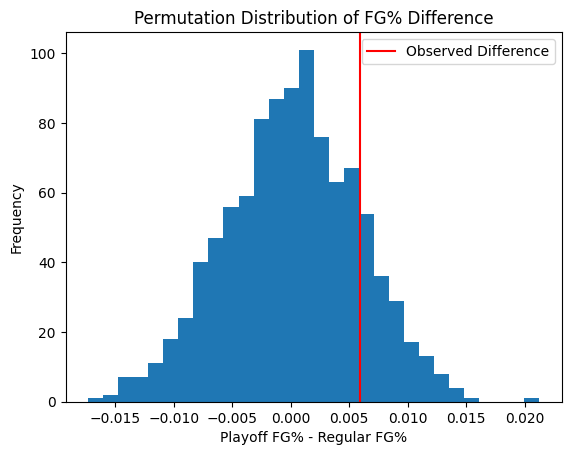

In [7]:
plt.hist(simulated_diffs, bins=30)
plt.axvline(observed_diff, color='red', label='Observed Difference')
plt.legend()
plt.title("Permutation Distribution of FG% Difference")
plt.xlabel("Playoff FG% - Regular FG%")
plt.ylabel("Frequency")
plt.show()

## P-Value Calculation

The p-value represents the probability of observing a difference at least as extreme as the one found in the data, assuming the null hypothesis is true.

In [8]:
p_value = np.mean(simulated_diffs >= observed_diff)

p_value

np.float64(0.16)

In [14]:
extreme = simulated_diffs >= observed_diff

extreme_count = np.sum(extreme)

print("Extreme count:", extreme_count)
print("Total simulations:", len(simulated_diffs))
print("P-value:", extreme_count / len(simulated_diffs))

Extreme count: 160
Total simulations: 1000
P-value: 0.16


## Conclusion

The observed difference in field goal percentage is about +0.006, meaning the playoff FG% is slightly higher than the regular season FG% in this dataset.

The permutation test gave a p-value of 0.16, which means a difference this large could reasonably happen by random chance if there was truly no difference.

Because the p-value is greater than 0.05, there is not enough evidence to reject the null hypothesis.

The results do not support the claim that NBA star players perform worse in the playoffs. The data suggests their playoff performance is about the same as regular season performance, or slightly better, but the difference is not statistically significant.

## Bootstrap Confidence Intervals

Bootstrapping is used to estimate uncertainty around the FG% difference between playoffs and regular season.

Two metrics are used:
- Mean FG% difference
- Median FG% difference

The median is included because the Central Limit Theorem does not apply to the median in the same direct way it applies to means.

In [9]:
num_bootstrap = 1000

mean_diffs = []
median_diffs = []

for _ in range(num_bootstrap):
    playoff_sample = np.random.choice(playoff_fg, size=len(playoff_fg), replace=True)
    regular_sample = np.random.choice(regular_fg, size=len(regular_fg), replace=True)
    
    mean_diffs.append(playoff_sample.mean() - regular_sample.mean())
    median_diffs.append(np.median(playoff_sample) - np.median(regular_sample))

mean_ci = np.percentile(mean_diffs, [2.5, 97.5])
median_ci = np.percentile(median_diffs, [2.5, 97.5])

mean_ci, median_ci

(array([-0.00417006,  0.01694627]), array([-0.005,  0.026]))

## Bootstrap Results

The bootstrap confidence intervals estimate the likely range of the true difference between playoff and regular season FG%.

If the interval includes 0, that means the difference could reasonably be no real difference.

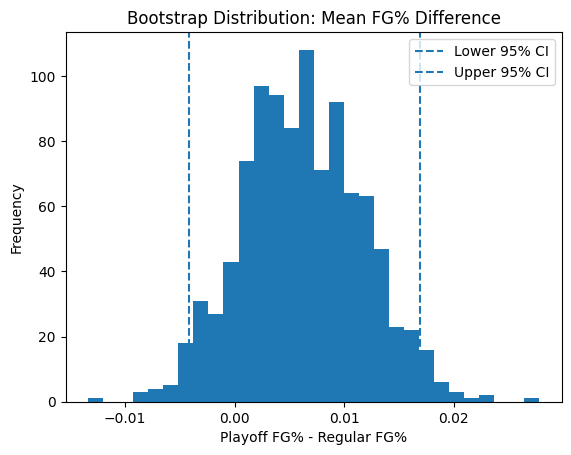

In [10]:
plt.hist(mean_diffs, bins=30)
plt.axvline(mean_ci[0], linestyle="--", label="Lower 95% CI")
plt.axvline(mean_ci[1], linestyle="--", label="Upper 95% CI")
plt.title("Bootstrap Distribution: Mean FG% Difference")
plt.xlabel("Playoff FG% - Regular FG%")
plt.ylabel("Frequency")
plt.legend()
plt.show()

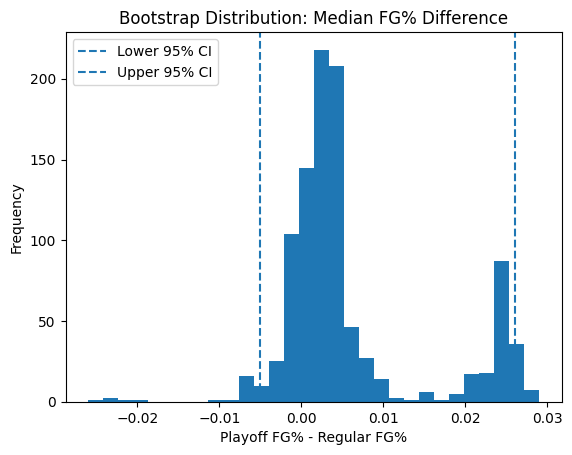

In [11]:
plt.hist(median_diffs, bins=30)
plt.axvline(median_ci[0], linestyle="--", label="Lower 95% CI")
plt.axvline(median_ci[1], linestyle="--", label="Upper 95% CI")
plt.title("Bootstrap Distribution: Median FG% Difference")
plt.xlabel("Playoff FG% - Regular FG%")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Bootstrap Interpretation

The 95% confidence interval for the mean FG% difference is approximately:

[-0.0059, 0.0166]

The 95% confidence interval for the median FG% difference is approximately:

[-0.0060, 0.0261]

Both intervals include 0, which means that a true difference of zero is plausible. In other words, there may be no real difference between playoff and regular season FG%.

These results are consistent with the permutation test, which also suggested that the observed difference could have occurred by random chance.

Overall, the bootstrap results reinforce the conclusion that there is not enough evidence to support the claim that players perform worse in the playoffs.